### DQN

当状态或者动作连续的时候，就有无限个状态动作对，我们更加无法使用这种表格形式来记录各个状态动作对的Q值。

对于这种情况：
- 我们需要用函数拟合的方法来估计Q值，即将这个复杂的Q值表格视作数据，使用一个参数化的函数$Q_θ$来拟合这些数据。
- 很显然，这种函数拟合的方法存在一定的精度损失，因此被称为**近似方法**。
- 我们今天要介绍的 DQN 算法便可以用来解决连续状态下离散动作的问题。


由于神经网络具有强大的表达能力，因此我们可以用一个神经网络来表示函数Q

- 若动作是**连续**（无限）的，神经网络的输入是状态s和动作a，然后输出一个标量，表示在状态下采取动作能获得的价值。
- 若动作是**离散**（有限）的，除了可以采取动作连续情况下的做法，我们还可以只将状态s输入到神经网络中，使其同时输出每一个动作的值

<font color="red">通常 DQN（以及 Q-learning）只能处理动作离散的情况，因为在函数Q的更新过程中有max_a这一操作。<font>




由于 DQN 是离线策略算法:
- 因此我们在收集数据的时候可以使用一个-贪婪策略来平衡探索与利用，将收集到的数据存储起来，在后续的训练中使用。
- DQN 中还有两个非常重要的模块——**经验回放和目标网络**，它们能够帮助 DQN 取得稳定、出色的性能。



In [2]:
from IPython.display import Image

#  Q 网络的损失函数是什么呢？

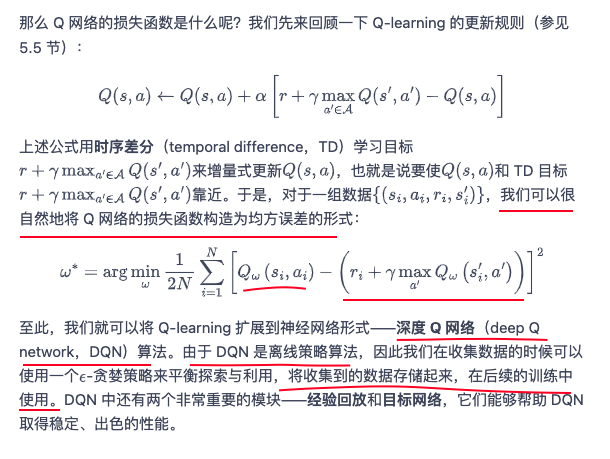

In [4]:
Image(filename='./image/dqn_loss.png',width=600)

# 目标网络

DQN 算法最终更新的目标是让$Q_w{(s,a)}$逼近TD目标：$r + γmax_{a`}{Q_w{(s`,a`)}}$，
- 由于 TD 误差目标本身就包含神经网络的输出，**因此在更新网络参数的同时目标也在不断地改变，这非常容易造成神经网络训练的不稳定性。**
- 为了解决这一问题，DQN 便使用了目标网络（target network）的思想：既然训练过程中 Q 网络的不断更新会导致目标不断发生改变，不如暂时先将 TD 目标中的 Q 网络固定住。为了实现这一思想，我们需要利用两套 Q 网络。

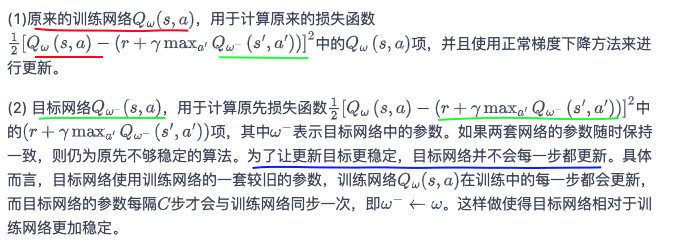

In [6]:
Image(filename="./image/targetnet.png",width=600)

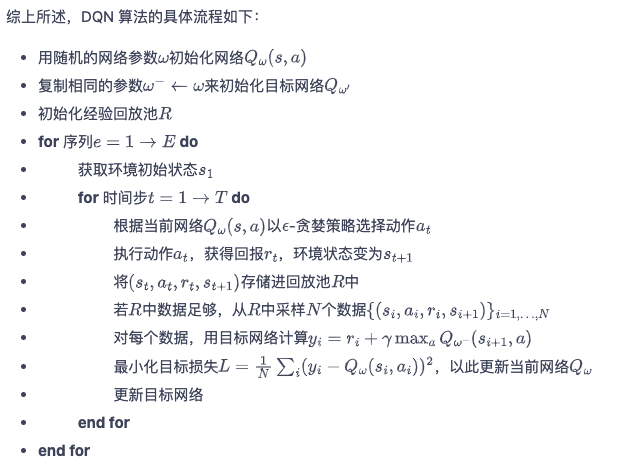

In [3]:
Image(filename="./image/dqn.png")

In [8]:
import  random
import gym
import numpy
import collections
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/

In [ ]:
# 经验回放池
class ReplayBuffer:
    def __init__(self,capacity):
        self.buffer = collections.deque(maxlen=capacity)
    def add(self,state,action,reward,next_state,done):
        self.buffer.append((state,action,reward,next_state,done))
    def sample(self,batch_size):
        transitons = random.sample(self.buffer,batch_size)
        state,action,reward,next_state,done = zip(*transitons)
        return np.array(state),action,reward,np.array(next_state),done
    def size(self):
        return len(self.buffer)

In [13]:
# 定义一个只有一层隐藏网络的Q网络
class Qnet(torch.nn.Module):
    def __int__(self,state_dim,hidden_dim,action_dim):
        super(Qnet,self).__int__()
        self.fc1 = torch.nn.linear(state_dim,hidden_dim)
        self.fc2 = torch.nn.linear(hidden_dim,action_dim)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
'''DQN算法'''
class DQN:
    def __init__(self,state_dim,hidden_dim,action_dim,learning_rate,gamma,epsilon,target_update,device):
        self.action_dim = action_dim
        #Q网络
        self.q_net = Qnet(state_dim,hidden_dim,action_dim).to(device)
        #目标网络
        self.target_q_net = Qnet(state_dim,hidden_dim,action_dim).to(device)
        # 用损失函数，只更新Q网络
        self.optimizer = torch.optim.Adam(self.q_net.parameters(),lr=learning_rate)
        self.gamma = gamma
        self.epsilon = epsilon
        # 使用Q网络更新目标网络
        self.target_update = target_update # 目标网络更新频率
        self.count = 0 # 记录更新的次数
        self.device = device
        
    def take_action(self,state):
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state],dtype = torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
        return action
    
    def update(self,transition_dict):
        states = torch.tensor(transition_dict['state'],dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['reward'],dtype=torch.float).view(-1,1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],dtype=torch.float).view(-1,1).to(self.device)
        next_states = torch.tensor(transition_dict['next_state'],dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],dtype=torch.float).view(-1,1).to(self.device)
        
        # Q值（每个状态选择动作之后得到的q值）
        q_values = self.q_net(states).gather(1,actions) 
        # 用目标网络计算：下一个状态的最大Q值
        max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1,1)
        # TD目标
        q_targets = rewards + self.gamma * max_next_q_values*(1-dones)
        # 计算损失
        dqn_loss = torch.mean(F.mse_loss(q_values,q_targets))
        self.optimizer.zero_grad()
        dqn_loss.backward()# 反向传播更新参数
        self.optimizer.step()
        
        # slow更新目标网络
        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())
        self.count +=1
        

In [ ]:
lr = 2e-3
num_episodes = 500
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 10 # 每隔10次更新一次目标网络
buffer_size = 10000
minimal_size = 500
batch_size = 64

device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v0'
env = gym.make(env_name)

random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)

replay_buffer = ReplayBuffer(buffer_size)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# 用DQN来拟合
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update, device)

return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):
            episode_return = 0
            state = env.reset()
            done = False
            while not done:
                
                action = agent.take_action(state)
                next_state, reward, done, _ = env.step(action)
                
                replay_buffer.add(state, action, reward, next_state, done)
                
                state = next_state
                episode_return += reward
                
                # 当buffer数据的数量超过一定值后,才进行Q网络训练
                if replay_buffer.size() > minimal_size:
                    b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)
                    transition_dict = {
                        'states': b_s,
                        'actions': b_a,
                        'next_states': b_ns,
                        'rewards': b_r,
                        'dones': b_d
                    }
                    # 更新
                    agent.update(transition_dict)
                    
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

In [ ]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

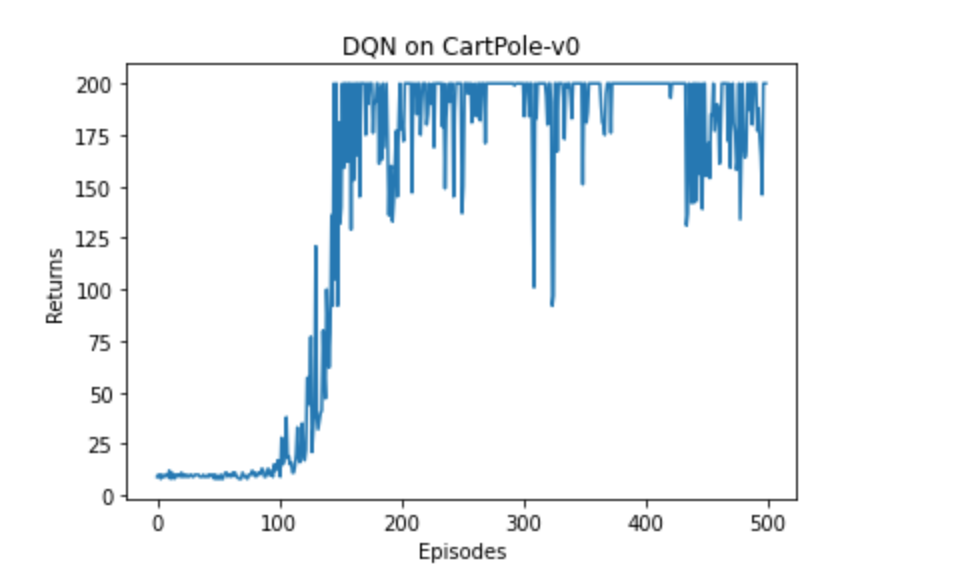

In [5]:
Image(filename="./image/no_average.png",width=600)

In [ ]:
# 使用移动平均，是一种数据平滑技术，用于减少数据的噪声，突出优势
mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

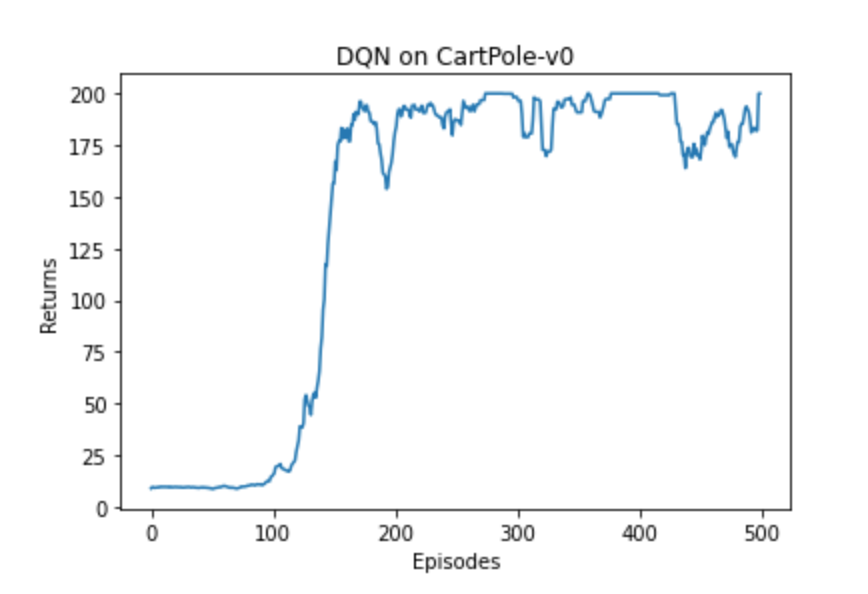

In [7]:
'''使用移动平均之后的效果'''
Image(filename="./image/average.png",width=600)


# 以图像为输入的 DQN 算法

在本书前面章节所述的强化学习环境中，我们都使用非图像的状态作为输入（例如车杆环境中车的坐标、速度）
- 但是在一些视频游戏中，智能体并不能直接获取这些状态信息，而只能直接获取屏幕中的图像。

- 要让智能体和人一样玩游戏，我们需要让智能体学会以图像作为状态时的决策。我们可以利用 7.4 节的 DQN 算法，**将卷积层加入其网络结构以提取图像特征**，最终实现以图像为输入的强化学习。
- 以图像为输入的 DQN 算法的代码与 7.4 节的代码的不同之处主要在于 Q 网络的结构和数据输入。
- DQN 网络通常会**将最近的几帧图像一起作为输入**，从而感知环境的动态性。接下来我们实现以图像为输入的 DQN 算法，但由于代码需要运行较长的时间，我们在此便不展示训练结果。

In [9]:
class ConvolutionalQnet(torch.nn.Module):
    ''' 加入卷积层的Q网络 '''
    def __init__(self, action_dim, in_channels=4):
        super(ConvolutionalQnet, self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels, 32, kernel_size=8, stride=4)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = torch.nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc4 = torch.nn.Linear(7 * 7 * 64, 512)
        self.head = torch.nn.Linear(512, action_dim)

    def forward(self, x):
        x = x / 255
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.fc4(x))
        return self.head(x)


本章讲解了 DQN 算法，其主要思想是用一个神经网络来表示最优策略的函数，然后利用 Q-learning 的思想进行参数更新。

为了保证训练的稳定性和高效性，DQN 算法引入了经验回放和目标网络两大模块，使得算法在实际应用时能够取得更好的效果。

DQN 是深度强化学习的基础，掌握了该算法才算是真正进入了深度强化学习领域，本书中还有更多的深度强化学习算法等待读者探索。
